<center><h1>Xie_Chong_HW5</h1></center>
<br>
<br>

Name: Chong Xie
<br>
Github Username: cxieusc
<br>
USC ID: 6800668300

## 1. Decision Trees as Interpretable Models

Import packages

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree,_tree
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

### (a) Obtain Data

Import the Accute Inamations Data Set

In [2]:
diagnosis_columns = [
    "temperature",
    "nausea",
    "lumbar-pain",
    "urine-pushing",
    "micturition-pains",
    "burning-urethra",
    "bladder-inflammation",
    "nephritis",
]

df = pd.read_csv(
    "../data/diagnosis.data",
    sep="\t",
    encoding="utf-16",
    decimal=",",
    header=None,
    names=diagnosis_columns,
)

df.head(5)

,temperature,nausea,lumbar-pain,urine-pushing,micturition-pains,burning-urethra,bladder-inflammation,nephritis
0,35.5,no,yes,no,no,no,no,no
1,35.9,no,no,yes,yes,yes,yes,no
2,35.9,no,yes,no,no,no,no,no
3,36.0,no,no,yes,yes,yes,yes,no
4,36.0,no,yes,no,no,no,no,no


### (b) Build a decision tree

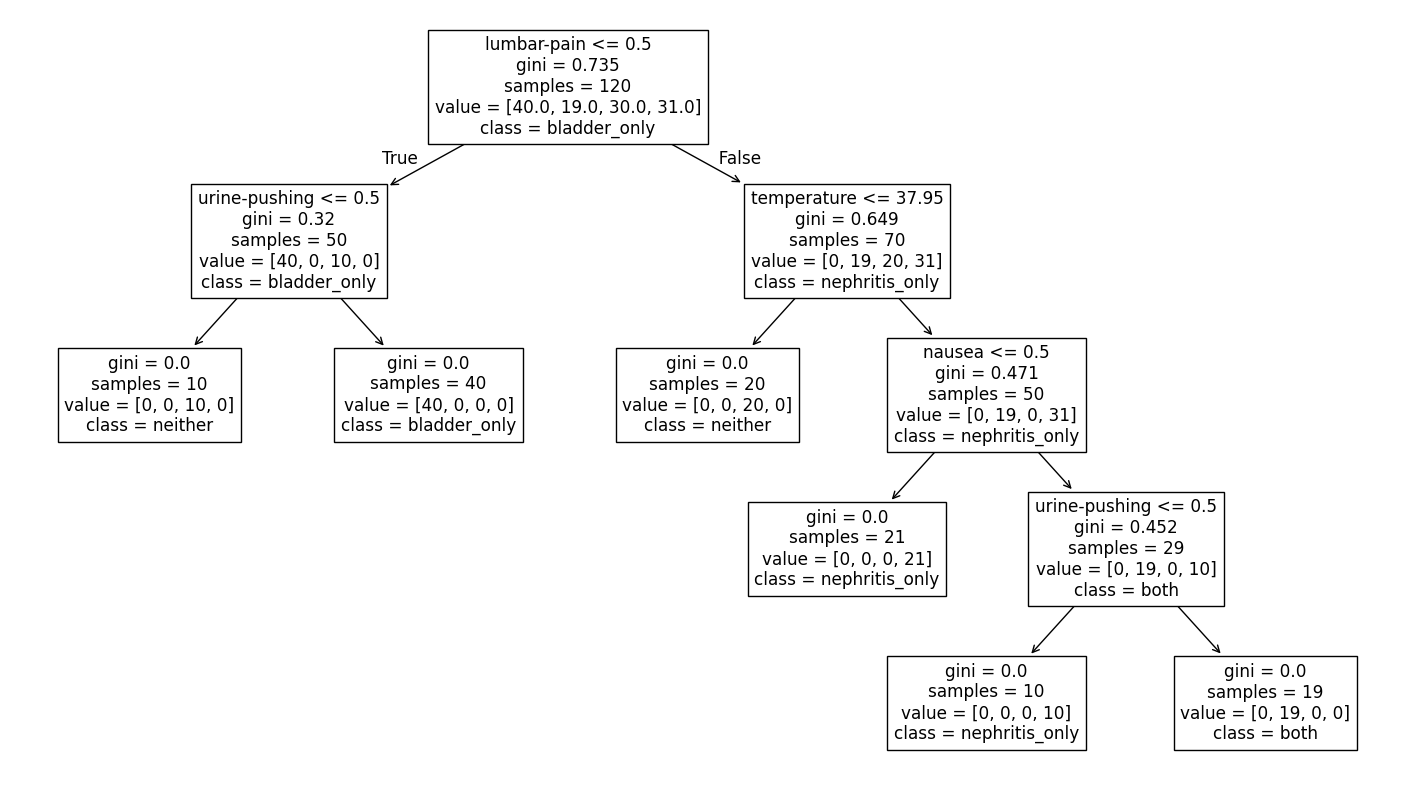

In [3]:
features = diagnosis_columns[:-2]
targets = diagnosis_columns[-2:]
X = df[features].copy()

for col in X.columns[1:]:
    X[col] = X[col].map({"no": 0, "yes": 1})

label_map = {
    ("no", "no"): "neither",
    ("yes", "no"): "bladder_only",
    ("no", "yes"): "nephritis_only",
    ("yes", "yes"): "both",
}

y = df[targets].apply(
    lambda row: label_map[tuple(row)],
    axis=1,
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X, y)

plt.figure(figsize=(18, 10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=dt.classes_,
)
plt.show()

### (c) Convert the decision rules

This code was taken from https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html as said in the homework PDF

In [4]:
def tree_to_pseudo(tree, feature_names):
	"""
	Outputs a decision tree model as if/then pseudocode
	
	Parameters:
	-----------
	tree: decision tree model
		The decision tree to represent as pseudocode
	feature_names: list
		The feature names of the dataset used for building the decision tree
	"""

	left = tree.tree_.children_left
	right = tree.tree_.children_right
	threshold = tree.tree_.threshold
	features = [feature_names[i] for i in tree.tree_.feature]
	value = tree.tree_.value

	def recurse(left, right, threshold, features, node, depth=0):
		indent = "  " * depth
		if (threshold[node] != -2):
			print(indent,"if ( " + features[node] + " <= " + str(threshold[node]) + " ) {")
			if left[node] != -1:
				recurse (left, right, threshold, features, left[node], depth+1)
				print(indent,"} else {")
				if right[node] != -1:
					recurse (left, right, threshold, features, right[node], depth+1)
				print(indent,"}")
		else:
			print(indent,"return " + str(value[node]))

	recurse(left, right, threshold, features, 0)

In [5]:
tree_to_pseudo(dt, X.columns)

 if ( lumbar-pain <= 0.5 ) {
   if ( urine-pushing <= 0.5 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[1. 0. 0. 0.]]
   }
 } else {
   if ( temperature <= 37.95000076293945 ) {
     return [[0. 0. 1. 0.]]
   } else {
     if ( nausea <= 0.5 ) {
       return [[0. 0. 0. 1.]]
     } else {
       if ( urine-pushing <= 0.5 ) {
         return [[0. 0. 0. 1.]]
       } else {
         return [[0. 1. 0. 0.]]
       }
     }
   }
 }


### (d) Cost-Complexity Pruning

In [6]:
path = dt.cost_complexity_pruning_path(X, y)

results = []

for alpha in path.ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
    )
    model.fit(X, y)

    results.append({
        "ccp_alpha": alpha,
        "depth": model.get_depth(),
        "leaves": model.get_n_leaves(),
        "training_accuracy": model.score(X, y),
    })

pruning_results = pd.DataFrame(results)
pruning_results

,ccp_alpha,depth,leaves,training_accuracy
0,0.000000,4,6,1.000000
1,0.098167,2,4,0.841667
2,0.133333,2,3,0.758333
3,0.182000,1,2,0.591667
4,0.222917,0,1,0.333333


In [7]:
eligible = pruning_results[
    pruning_results["training_accuracy"] >= 0.80
]

selected = eligible.sort_values(
    ["leaves", "ccp_alpha"]
).iloc[0]

selected_alpha = float(selected["ccp_alpha"])

pruned_dt = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=selected_alpha,
)
pruned_dt.fit(X, y)

print("Selected alpha:", selected_alpha)
print("Tree depth:", pruned_dt.get_depth())
print("Number of leaves:", pruned_dt.get_n_leaves())
print("Training accuracy:", pruned_dt.score(X, y))

Selected alpha: 0.09816666666666667
Tree depth: 2
Number of leaves: 4
Training accuracy: 0.8416666666666667


I used cost-complexity pruning to generate a sequence of simpler trees. Among the candidate trees with training accuracy of at least 80%, I selected the tree with the fewest leaves. The selected alpha is approximately 0.098167. Pruning reduces the depth from 4 to 2 and the number of leaves from 6 to 4, while training accuracy decreases from 100% to 84.17%. The resulting rules are shorter and easier to interpret, at the cost of classification accuracy.

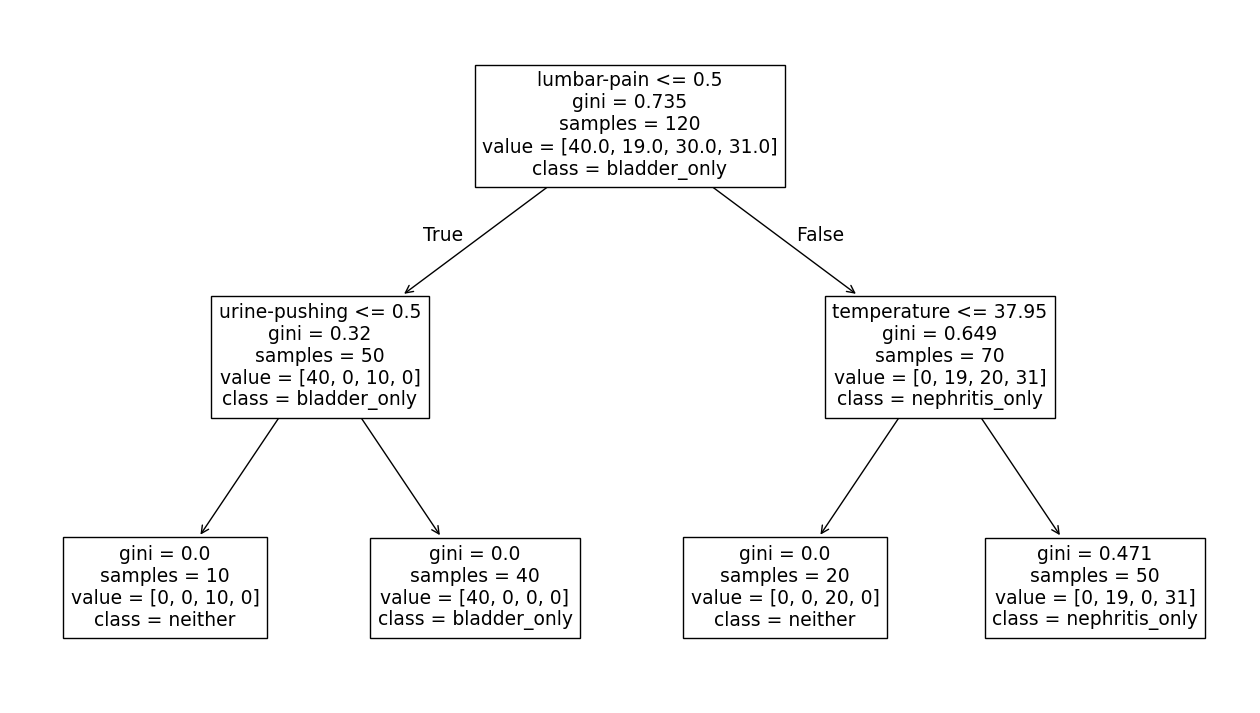

In [8]:
plt.figure(figsize=(16, 9))
plot_tree(
    pruned_dt,
    feature_names=X.columns,
    class_names=pruned_dt.classes_,
)
plt.show()

In [9]:
tree_to_pseudo(pruned_dt, X.columns)

 if ( lumbar-pain <= 0.5 ) {
   if ( urine-pushing <= 0.5 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[1. 0. 0. 0.]]
   }
 } else {
   if ( temperature <= 37.95000076293945 ) {
     return [[0. 0. 1. 0.]]
   } else {
     return [[0.   0.38 0.   0.62]]
   }
 }


## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [10]:
df2 = pd.read_csv(
    "../data/communities.data",
    sep=",",
    header=None,
    na_values="?",
)

df2.head(5)

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [11]:
train_data = df2.iloc[:1495].copy()
test_data = df2.iloc[1495:].copy()

### (b) Missing values

In [12]:
# Drop the first 5 columns (Non-features) and the last column (the target variable) for features
X_train = train_data.iloc[:, 5:-1].copy()
X_test = test_data.iloc[:, 5:-1].copy()

y_train = train_data.iloc[:, -1].copy()
y_test = test_data.iloc[:, -1].copy()

train_means = X_train.mean()

X_train = X_train.fillna(train_means)
X_test = X_test.fillna(train_means)

### (c) Plot a correlation matrix

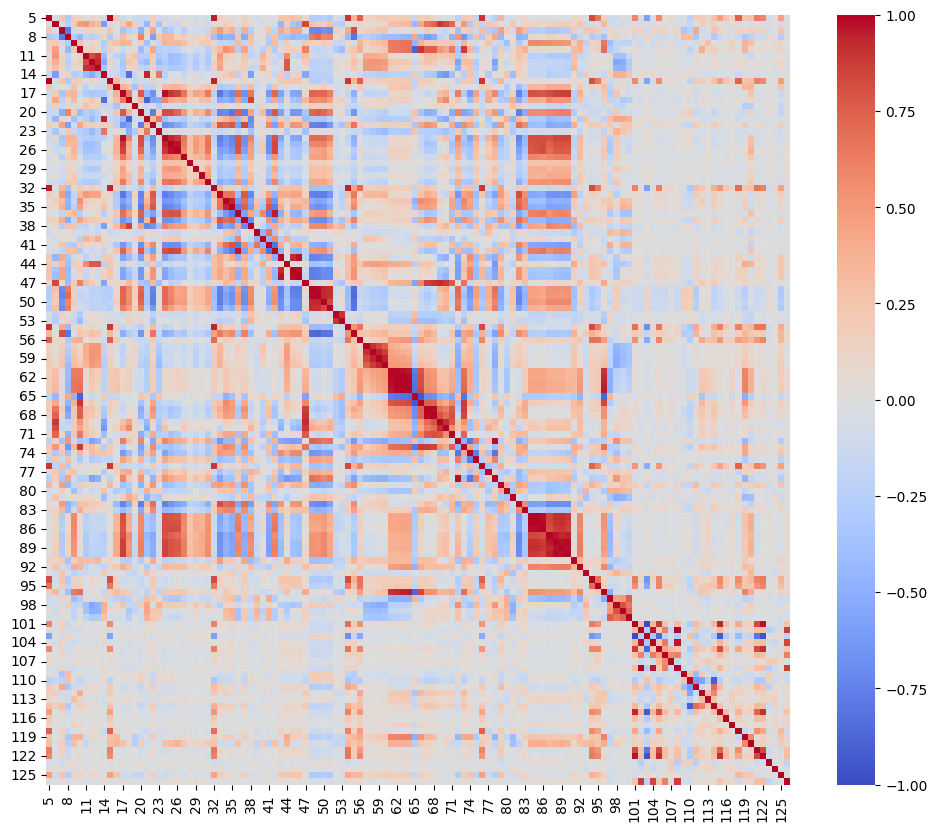

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

### (d) Calculate the Coefficient of Variation CV

In [14]:
cv = X_train.std(ddof=1) / X_train.mean()
cv

5      2.241105
6      0.355800
7      1.428885
8      0.330213
9      1.359100
         ...   
122    0.743487
123    0.115739
124    0.362989
125    2.552946
126    0.326026
Length: 122, dtype: float64

### (e) Scatter plots and box plots for highest CV features

In [15]:
top_features = cv.nlargest(11).index
cv.loc[top_features].to_frame(name="CV")

,CV
95,4.292923
94,3.470952
54,3.058964
56,2.926635
125,2.552946
32,2.342443
5,2.241105
15,2.038461
76,1.968467
118,1.645408


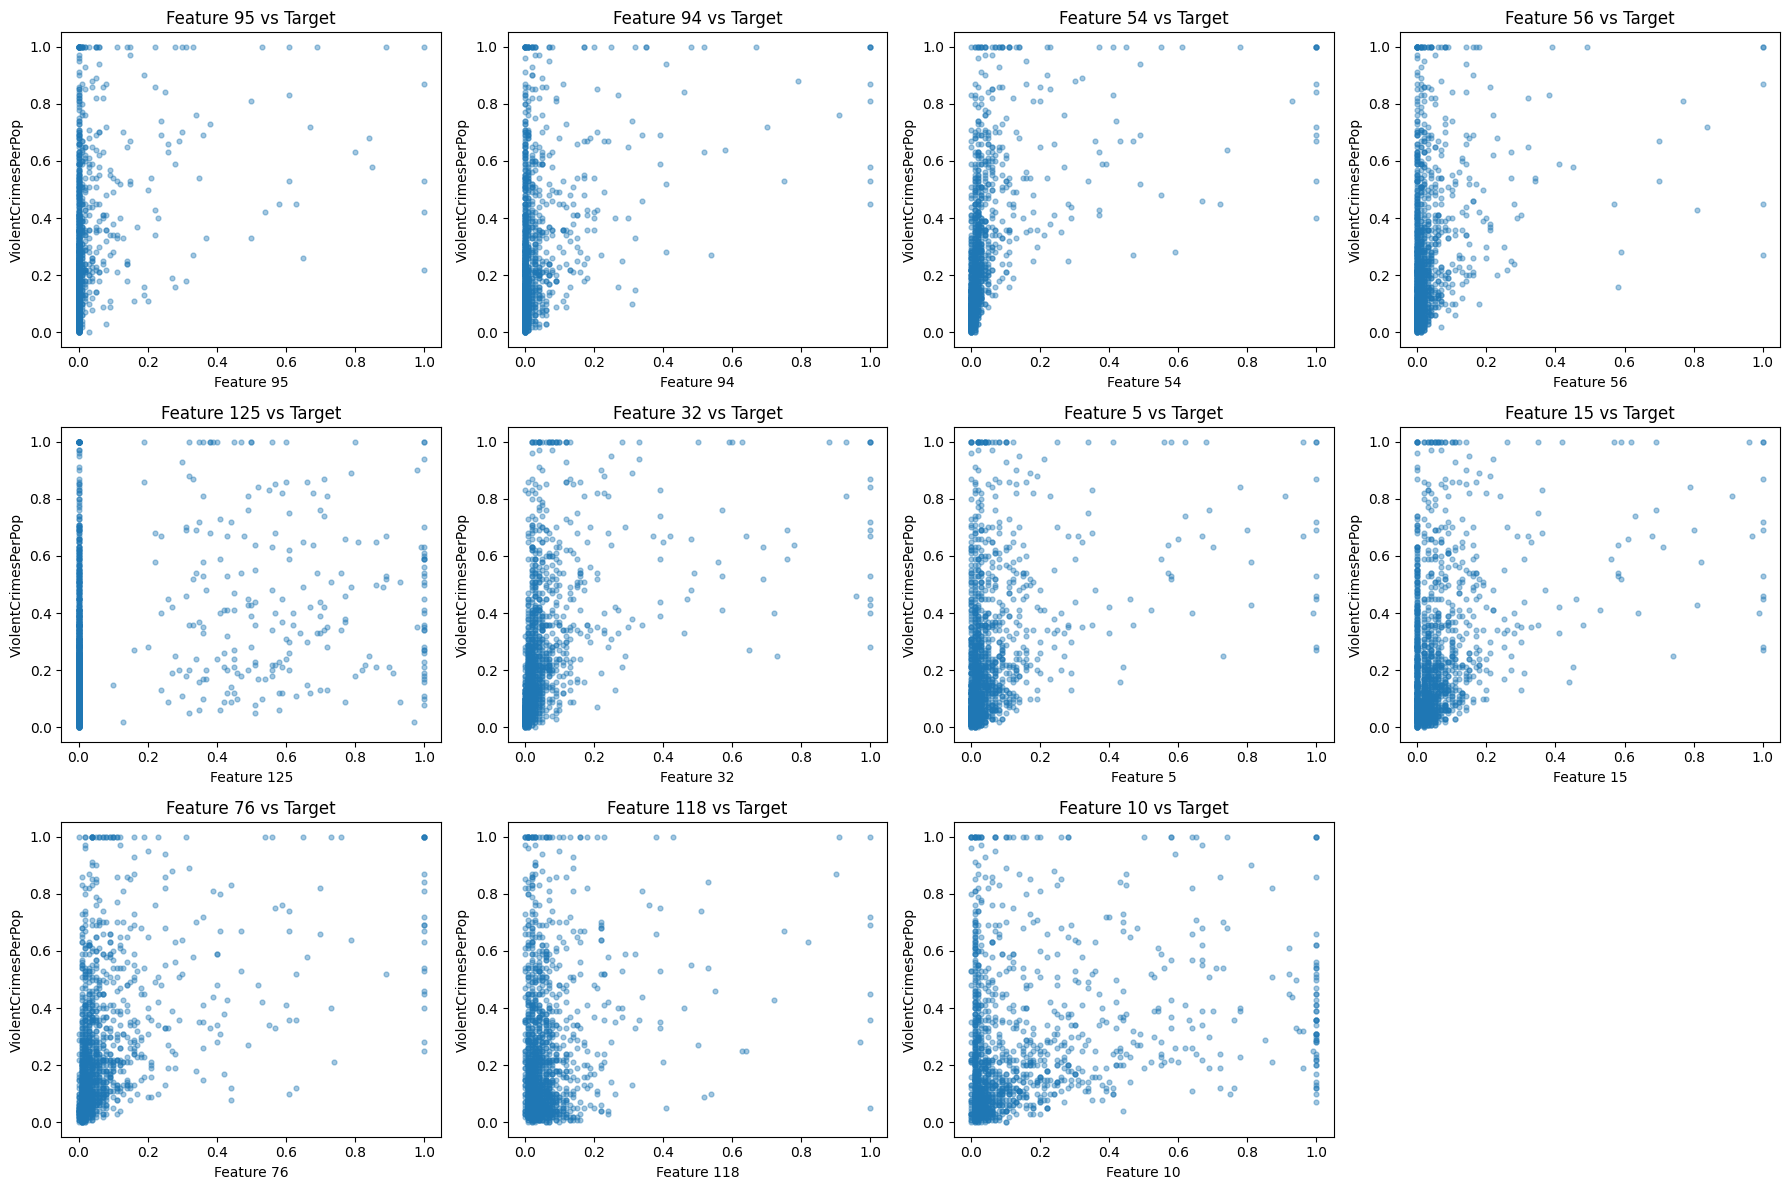

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    axes[i].scatter(
        X_train[feature],
        y_train,
        alpha=0.4,
        s=12,
    )
    axes[i].set_xlabel(f"Feature {feature}")
    axes[i].set_ylabel("ViolentCrimesPerPop")
    axes[i].set_title(f"Feature {feature} vs Target")

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

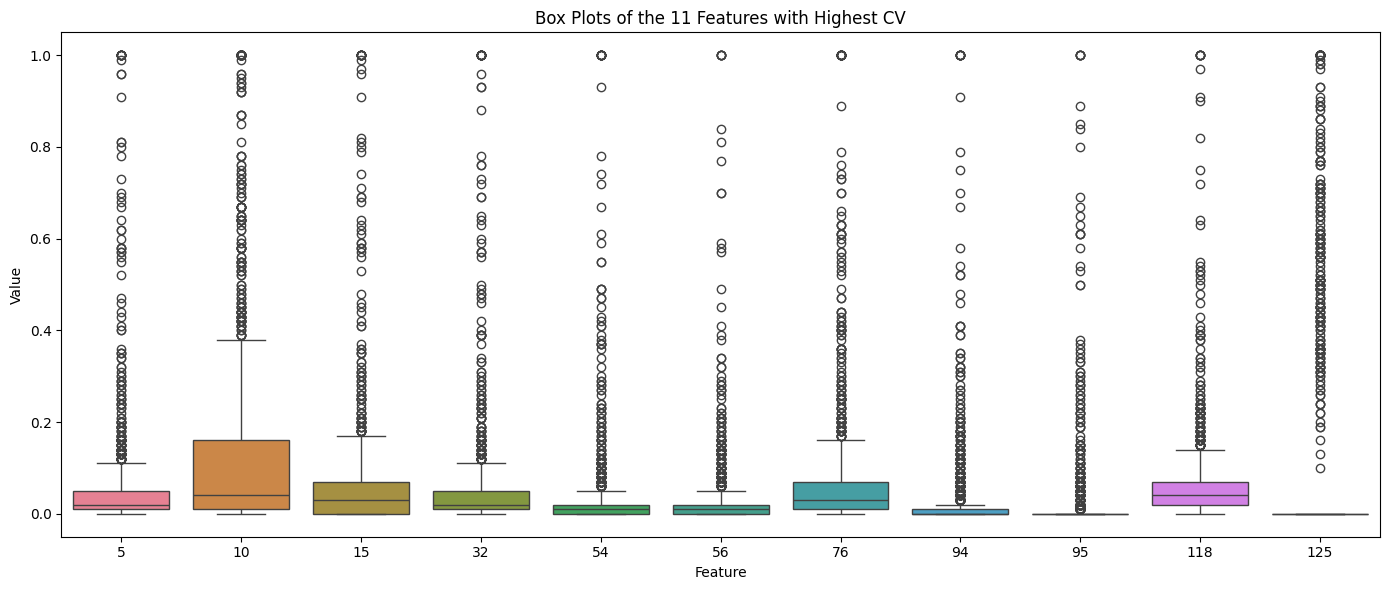

In [17]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=X_train[top_features])

plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Box Plots of the 11 Features with Highest CV")
plt.tight_layout()
plt.show()

Most selected features are strongly right-skewed, with many observations near zero and relatively few large values. Most selected features are strongly right-skewed, with many observations near zero and relatively few large values.

### (f) Fit a linear model

In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)
loss_linear = mean_squared_error(y_test, y_pred)
print("Mean Squared Error of Linear Regression:", loss_linear)

Mean Squared Error of Linear Regression: 0.01814197113553011


### (g) Fit a ridge regression model

In [19]:
param_grid = {
    "alpha": np.logspace(-4, 4, 100)
}   # Get 100 candidate alpha values from 10^-4 to 10^4

ridge_search = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
)
ridge_search.fit(X_train, y_train)

y_pred = ridge_search.predict(X_test)
loss_ridge = mean_squared_error(y_test, y_pred)
print('MSE of Ridge Regression:', loss_ridge)

MSE of Ridge Regression: 0.0175996137924525


### (h) Fit a LASSO model

In [30]:
lasso_search = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
)

lasso_search.fit(X_train, y_train)
y_pred = lasso_search.predict(X_test)
loss_lasso1 = mean_squared_error(y_test, y_pred)
print('MSE of Lasso Regression without standardization:', loss_lasso1)

lasso_raw = lasso_search.best_estimator_

selected_raw = X_train.columns[
    lasso_raw.coef_ != 0
].tolist()

print("Best alpha:", lasso_search.best_params_["alpha"])
print("Selected features:", selected_raw)
print("Number of selected features:", len(selected_raw))

MSE of Lasso Regression without standardization: 0.017747189310170428
Best alpha: 0.00012045035402587823
Selected features: [7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 41, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 57, 60, 64, 66, 68, 69, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 87, 90, 91, 92, 93, 94, 95, 96, 97, 99, 104, 105, 107, 109, 111, 113, 115, 116, 117, 118, 119, 120, 123, 124, 125, 126]
Number of selected features: 76


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

X_train_raw = train_data.iloc[:, 5:-1].copy()
X_test_raw = test_data.iloc[:, 5:-1].copy()

lasso_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000)),
])

lasso_scaled_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid={"lasso__alpha": param_grid["alpha"]},
    scoring="neg_mean_squared_error",
    cv=5,
)

lasso_scaled_search.fit(X_train_raw, y_train)

y_pred = lasso_scaled_search.predict(X_test_raw)
loss_lasso2 = mean_squared_error(y_test, y_pred)

lasso_scaled = (
    lasso_scaled_search.best_estimator_.named_steps["lasso"]
)

selected_scaled = X_train_raw.columns[
    lasso_scaled.coef_ != 0
].tolist()

print("MSE of Lasso Regression with standardization:", loss_lasso2)
print("Best alpha:", lasso_scaled_search.best_params_["lasso__alpha"])
print("Selected features:", selected_scaled)
print("Number of selected features:", len(selected_scaled))

MSE of Lasso Regression with standardization: 0.017802067664998096
Best alpha: 0.000774263682681127
Selected features: [7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 58, 60, 64, 66, 68, 69, 72, 73, 74, 76, 77, 79, 80, 81, 82, 83, 87, 90, 91, 92, 93, 94, 95, 96, 99, 104, 105, 107, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 123, 124]
Number of selected features: 73


The test error for LASSO without standardized features is 0.017747 with 76 features selected, while the test error with standardized features is 0.017802 with 73 features selected.

Thus, standardization produces a slightly sparser model but does not improve test performance in this experiment.

### (i) Fit a PCR model

### (j) Fit a boosting tree